# 第4章：Implementing a GPT Model from Scratch

**目标：** 从零搭建完整的 GPT 模型架构，并实现简单的文本生成

```
DummyGPT(整体骨架) → LayerNorm → GELU + FeedForward → 残差连接 → TransformerBlock → GPTModel → 文本生成
```

**前置回顾（第2、3章）：**
- 文本经过 BPE 分词 → Token Embedding + Positional Embedding → 输入向量 `(batch, seq_len, emb_dim)`
- Multi-Head Causal Attention 让每个 token 融合上下文信息，输出 shape 不变
- 现在的问题：光有注意力还不够，还需要 **LayerNorm、FeedForward、残差连接** 才能组成完整的 Transformer Block，多个 Block 堆叠才构成 GPT

---

## 4.1 GPT 架构概览 ⭐

GPT 属于 **decoder-only** 架构（只用了原始 Transformer 的解码器部分）。

**GPT-2 (124M) 的核心配置：**

| 参数 | 值 | 含义 |
|------|-----|------|
| `vocab_size` | 50,257 | BPE 词汇表大小 |
| `context_length` | 1,024 | 最大输入 token 数 |
| `emb_dim` | 768 | 嵌入维度 |
| `n_heads` | 12 | 注意力头数 |
| `n_layers` | 12 | Transformer Block 层数 |
| `drop_rate` | 0.1 | Dropout 比率 |
| `qkv_bias` | False | Q/K/V 投影是否带偏置 |

**整体数据流：**
```
Token IDs
   ↓
Token Embedding + Position Embedding
   ↓ Dropout
┌─────────────────────────────┐
│     Transformer Block × 12  │
│  ┌─────────────────────┐    │
│  │ LayerNorm            │    │
│  │ Multi-Head Attention  │    │
│  │ Dropout + Residual   │    │
│  │ LayerNorm            │    │
│  │ FeedForward          │    │
│  │ Dropout + Residual   │    │
│  └─────────────────────┘    │
└─────────────────────────────┘
   ↓
Final LayerNorm
   ↓
Linear (output head) → logits (vocab_size)
```

> 💡 **关键洞察：** GPT 架构虽然有 1.24 亿参数，但代码量并不大——大量元素是**重复堆叠**的。理解一个 Transformer Block，就理解了整个模型。

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# GPT-2 124M 配置
GPT_CONFIG_124M = {
    "vocab_size": 50257, # 词汇表大小
    "context_length": 1024,  #  上下文长度
    "emb_dim": 768, # 嵌入维度
    "n_heads": 12, # 注意力头数
    "n_layers": 12, # 编码器层数
    "drop_rate": 0.1, # 丢弃率
    "qkv_bias": False, # QKV 偏置
}

print("GPT-2 124M 配置:")
for k, v in GPT_CONFIG_124M.items():
    print(f"  {k}: {v}")

GPT-2 124M 配置:
  vocab_size: 50257
  context_length: 1024
  emb_dim: 768
  n_heads: 12
  n_layers: 12
  drop_rate: 0.1
  qkv_bias: False


### 先搭骨架：DummyGPT

我们先用占位符（Dummy）组件搭出 GPT 的整体骨架，确认数据流正确后，再逐步替换为真实实现。

In [15]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x   # 直接返回输入，只传递


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # 词嵌入层和位置嵌入层
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        # 随机丢弃率
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        # 转换器块
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        # 最后的层归一化和输出头
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [16]:
# 测试 DummyGPT 的数据流
tokenizer = tiktoken.get_encoding("gpt2")

batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
# 将文本编码为 token 序列
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
# 将 token 序列拼接成 batch
batch = torch.stack(batch, dim=0)

torch.manual_seed(123)
# 创建 DummyGPT 模型
model = DummyGPTModel(GPT_CONFIG_124M)
# 前向传播
logits = model(batch)

print(f"输入 batch shape: {batch.shape}")        # (2, 4)
print(f"输出 logits shape: {logits.shape}")       # (2, 4, 50257)
print(f"\n→ 每个 token 位置输出一个 {GPT_CONFIG_124M['vocab_size']} 维向量")
print(f"→ 代表该位置预测下一个 token 的 logits（未归一化概率）")

输入 batch shape: torch.Size([2, 4])
输出 logits shape: torch.Size([2, 4, 50257])

→ 每个 token 位置输出一个 50257 维向量
→ 代表该位置预测下一个 token 的 logits（未归一化概率）


> 💡 **关键洞察：** DummyGPT 虽然 TransformerBlock 和 LayerNorm 都是空壳，但数据流已经完全正确：
> - 输入 `(batch, seq_len)` 的 token IDs
> - 输出 `(batch, seq_len, vocab_size)` 的 logits
> 
> 接下来我们要做的就是**逐一替换**每个 Dummy 组件为真实实现。

---
## 4.2 Layer Normalization ⭐

**核心问题：** 深度网络训练时，每层输入的分布会不断变化（internal covariate shift），导致训练不稳定。

**LayerNorm 的做法：** 对每个样本的**特征维度**做归一化（均值→0，方差→1），然后加上可学习的缩放（scale）和偏移（shift）。

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

其中 $\mu$ 和 $\sigma^2$ 是沿最后一维计算的均值和方差，$\gamma$（scale）和 $\beta$（shift）是可学习参数。

**为什么是 LayerNorm 而不是 BatchNorm？**
- BatchNorm 沿 batch 维度归一化，在 NLP 中效果差（序列长度不一，batch 小时统计量不稳定）
- LayerNorm 沿特征维度归一化，**每个样本独立**，不依赖 batch 中的其他样本

In [17]:
# 先直观理解归一化的效果
torch.manual_seed(123)
batch_example = torch.randn(2, 5)  # 2个样本, 5个特征

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(f"层输出:\n{out}")

# 沿特征维度计算均值和方差
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print(f"\n均值: {mean.squeeze()}")
print(f"方差: {var.squeeze()}")
print("→ 不同样本的均值和方差差异较大")

层输出:
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

均值: tensor([0.1324, 0.2170], grad_fn=<SqueezeBackward0>)
方差: tensor([0.0231, 0.0398], grad_fn=<SqueezeBackward0>)
→ 不同样本的均值和方差差异较大


In [18]:
# 手动归一化
out_norm = (out - mean) / torch.sqrt(var)
mean_after = out_norm.mean(dim=-1, keepdim=True)
var_after = out_norm.var(dim=-1, keepdim=True)

torch.set_printoptions(sci_mode=False)
print(f"归一化后均值: {mean_after.squeeze()}")
print(f"归一化后方差: {var_after.squeeze()}")
print("→ 均值≈0, 方差≈1")

归一化后均值: tensor([0.0000, 0.0000], grad_fn=<SqueezeBackward0>)
归一化后方差: tensor([1.0000, 1.0000], grad_fn=<SqueezeBackward0>)
→ 均值≈0, 方差≈1


In [19]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        # 计算方差
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [20]:
# 验证我们的 LayerNorm
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)

mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print(f"LayerNorm 后均值: {mean.squeeze()}")
print(f"LayerNorm 后方差: {var.squeeze()}")
print("\n→ 方差不是精确的 1.0，因为加了 eps 防止除零")

LayerNorm 后均值: tensor([ 0.0000, -0.0000], grad_fn=<SqueezeBackward0>)
LayerNorm 后方差: tensor([0.9995, 0.9997], grad_fn=<SqueezeBackward0>)

→ 方差不是精确的 1.0，因为加了 eps 防止除零


### 🤔 思考：LayerNorm 的两个设计细节

| 设计 | 原因 |
|------|------|
| `scale` 和 `shift` 可学习 | 纯归一化可能丢失有用信息，scale/shift 让模型自己决定最佳分布 |
| `unbiased=False`（有偏方差） | GPT-2 原版使用有偏方差（除以 n 而非 n-1），对于 768 维来说差异极小，但为了兼容预训练权重而保持一致 |

> 💡 **GPT 中 LayerNorm 的位置（Pre-LN）：** GPT-2 采用 **Pre-LN** 架构——LayerNorm 放在注意力/FFN **之前**，而非之后。这种设计使训练更稳定，是目前 LLM 的标准做法。

### ✏️ 练习
1. `eps` 设为 `1e-5` 的作用是什么？如果去掉会怎样？
2. 如果把 `unbiased=False` 改成 `True`，结果会有多大差异？试试在 `emb_dim=768` 时对比两种方式的输出。

In [21]:
# 在这里做实验
1.
# 作用是避免除以零
# eps 防止除以零，保证数值稳定性。
2.
# 差异非常小（约 1/(n-1) 倍），在大维度下几乎可以忽略。
# false是有偏方差分母是n，true是五篇方差分母是n-1
# 验证代码
import torch

x = torch.randn(2, 4, 768)
var_biased = x.var(dim=-1, unbiased=False)
var_unbiased = x.var(dim=-1, unbiased=True)

print(f"差异比例: {(var_unbiased/var_biased - 1).mean():.6f}")
# 输出约 0.0013 (0.13%)

差异比例: 0.001304


---
## 4.3 GELU 激活函数与 FeedForward 网络 ⭐

Transformer Block 中，注意力层之后紧跟一个 **前馈网络（FeedForward Network, FFN）**。

FFN 的结构很简单：**两层线性变换夹一个激活函数**。

```
输入 (emb_dim=768)
   ↓ Linear(768, 3072)    ← 扩展 4 倍
   ↓ GELU 激活
   ↓ Linear(3072, 768)    ← 压缩回原维度
输出 (emb_dim=768)
```

### 为什么用 GELU 而不是 ReLU？

| | ReLU | GELU |
|---|---|---|
| 公式 | $\max(0, x)$ | $x \cdot \Phi(x)$ ，$\Phi$ 是标准正态 CDF |
| 特点 | 分段线性，x<0 时梯度为 0 | 平滑，x<0 时梯度不为零 |
| 优势 | 计算快 | 更好的梯度流动，LLM 训练效果更好 |

ReLU = max(0, x)：正数保留，负数变零。它简单高效，但因为负数直接变零，可能丢失信息。GPT 用 GELU 替换 ReLU，负数区域有微小输出，信息流动更顺畅。

In [22]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl

# ========== 重置所有 matplotlib 设置 ==========
mpl.rcParams.update(mpl.rcParamsDefault)

# ========== 设置中文字体 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

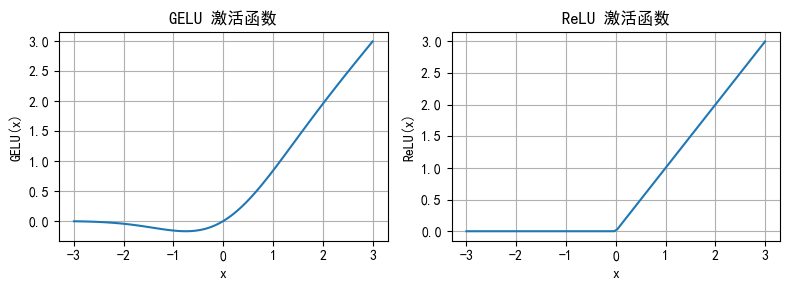

→ GELU 是平滑的，负数区域有微小非零输出
→ ReLU 是分段线性的，负数区域直接截断为 0


In [23]:
# 可视化 GELU vs ReLU
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)

plt.figure(figsize=(8, 3))
for i, (fn, label) in enumerate(zip([gelu, relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, fn(x))
    plt.title(f"{label} 激活函数")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

print("→ GELU 是平滑的，负数区域有微小非零输出")
print("→ ReLU 是分段线性的，负数区域直接截断为 0")

In [24]:
# FFN模块
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  #扩展
            GELU(),  # 激活
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # 压缩
        )

    def forward(self, x):
        return self.layers(x)

In [25]:
# 验证 FeedForward 的输入输出形状
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 4, 768)  # (batch, seq_len, emb_dim)
out = ffn(x)

print(f"FFN 输入 shape: {x.shape}")
print(f"FFN 输出 shape: {out.shape}")
print(f"\n→ 输入输出 shape 相同，中间经历 768→3072→768 的维度变化")

# 统计参数量
ffn_params = sum(p.numel() for p in ffn.parameters())
print(f"\nFFN 参数量: {ffn_params:,}")
print(f"  第一层: 768×3072 + 3072(bias) = {768*3072 + 3072:,}")
print(f"  第二层: 3072×768 + 768(bias) = {3072*768 + 768:,}")

FFN 输入 shape: torch.Size([2, 4, 768])
FFN 输出 shape: torch.Size([2, 4, 768])

→ 输入输出 shape 相同，中间经历 768→3072→768 的维度变化

FFN 参数量: 4,722,432
  第一层: 768×3072 + 3072(bias) = 2,362,368
  第二层: 3072×768 + 768(bias) = 2,360,064


> 💡 **关键洞察：为什么中间层要扩大 4 倍？**
>
> FFN 的 768→3072→768 设计被称为 **bottleneck**（瓶颈结构的反面——其实是**expansion**）。
> 扩大 4 倍可以让模型在更高维空间中做非线性变换，然后再压缩回原始维度。
> 这个 4 倍的比例在原始 Transformer 论文中就确定了，后来的 GPT、BERT 等都沿用了。

GPT-2 124M 参数分布：

Token Embedding:   ████████████████████ (31%)

Positional Emb:    █ (1%)

12层 MHA:          ████████████ (23%)

12层 FFN:          ████████████████████ (46%)  ← 接近一半！

输出层:            (与 Token Emb 共享)

其他:              █ (1%)

### ✏️ 练习
1. 计算一下：12 层 Transformer Block 中，所有 FFN 的总参数量是多少？占 GPT-2 124M 总参数的百分比？
2. 把 GELU 替换成 ReLU，对比一下 FFN 的输出有什么不同？

In [26]:
# 在这里做实验
1.
# 约 56.6M 参数，占总参数的 45.6%。
# 一共12层transformer，每层都一样，每一层两个函数，
# 一个函数是输入layernorm归一然后再多头再layernorm再FFN
# 下面的计算残差，就是用上面的输入的layer经过多头之后更新到x1，
# 然后再把这个x1当做输入layernorm归一继续FFn然后计算残差最后输出x2
# 所以每一层基本上就主要是多头和ffn一半一半了（大致思路）（下面会介绍残差连接）

2.
# 可能会因为变成零而丢失信息。
# 功能上差异不大（都能工作），但 ReLU 可能因「死亡神经元」略微降低模型表现。

2.0

---
## 4.4 残差连接（Shortcut / Skip Connection）⭐⭐

**核心问题：** 深度网络中，梯度在反向传播时可能逐层衰减，导致**梯度消失**——前面的层几乎学不到东西。

**残差连接的做法：** 跳过中间层，将输入直接加到输出上。

```
没有残差连接:    x → Layer → y
有残差连接:      x → Layer → y + x    ← 加上原始输入
```

**为什么有效？**
- 梯度可以通过 shortcut 直接传到前面的层（不需要经过所有中间层）
- 即使中间层输出接近 0，信号仍然可以通过

In [27]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape: 
                #这里是残差的判断条件 比较了维度相同与否，不相同不能相加
                x = x + layer_output # 有残差 x = x + f(x)
            else:
                x = layer_output # 无残差 x = f(x)
        return x

# 把原始输入加回来 ← 这就是残差

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()(output, target)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name}: 梯度绝对值均值 = {param.grad.abs().mean().item():.6f}")

In [28]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

print("=" * 60)
print("【无残差连接】")
print("=" * 60)
torch.manual_seed(123)
model_no_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)
print_gradients(model_no_shortcut, sample_input)

print("\n" + "=" * 60)
print("【有残差连接】")
print("=" * 60)
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

【无残差连接】
layers.0.0.weight: 梯度绝对值均值 = 0.000202
layers.1.0.weight: 梯度绝对值均值 = 0.000120
layers.2.0.weight: 梯度绝对值均值 = 0.000715
layers.3.0.weight: 梯度绝对值均值 = 0.001399
layers.4.0.weight: 梯度绝对值均值 = 0.005050

【有残差连接】
layers.0.0.weight: 梯度绝对值均值 = 0.221698
layers.1.0.weight: 梯度绝对值均值 = 0.206941
layers.2.0.weight: 梯度绝对值均值 = 0.328970
layers.3.0.weight: 梯度绝对值均值 = 0.266573
layers.4.0.weight: 梯度绝对值均值 = 1.325854


> 💡 **关键洞察：** 对比两种情况可以看到：
> - **无残差连接：** 越靠前的层（layer.0）梯度越小 → 梯度消失
> - **有残差连接：** 所有层的梯度都在合理范围内 → 训练更均匀
>
> 这就是为什么 Transformer 每个子层（注意力、FFN）都要加残差连接。

### ✏️ 练习
1. 如果把层数从 5 增加到 10 或 20，梯度消失的现象会更严重吗？用代码验证。
2. 残差连接要求 `x.shape == layer_output.shape`，如果两者 shape 不同怎么办？实际中是怎么处理的？

In [29]:
# 在这里做实验
1.
# 层数越多越严重
import torch
import torch.nn as nn

class DepthExperiment(nn.Module):
    def __init__(self, num_layers, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(3, 3), nn.ReLU())
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            if self.use_shortcut and x.shape == out.shape:
                x = x + out
            else:
                x = out
        return x

def check_gradients(num_layers, use_shortcut):
    model = DepthExperiment(num_layers, use_shortcut)
    x = torch.tensor([[1., 0., -1.]], requires_grad=True)
    output = model(x)
    loss = output.sum()
    loss.backward()
    
    # 提取第一层和最后一层的梯度
    first_grad = model.layers[0][0].weight.grad.abs().mean().item()
    last_grad = model.layers[-1][0].weight.grad.abs().mean().item()
    return first_grad, last_grad

# 测试不同层数
for num_layers in [5, 10, 20]:
    print(f"\n{'='*50}")
    print(f"层数: {num_layers}")
    
    # 无残差
    first, last = check_gradients(num_layers, use_shortcut=False)
    print(f"无残差: 首层梯度={first:.8f}, 末层梯度={last:.6f}")
    
    # 有残差
    first, last = check_gradients(num_layers, use_shortcut=True)
    print(f"有残差: 首层梯度={first:.6f}, 末层梯度={last:.6f}")

2.
# 不同的不能相加，应该还是可以转化的吧
# 通过线性投影（加一个可学习的矩阵）把 x 映射到 layer_output 的相同形状。
class ResidualBlock(nn.Module):
    def __init__(self, dim_in, dim_out, use_projection=False):
        super().__init__()
        self.layer = nn.Linear(dim_in, dim_out)
        self.use_projection = use_projection
        if use_projection:
            # 线性投影：把输入映射到输出维度
            self.shortcut = nn.Linear(dim_in, dim_out)
    
    def forward(self, x):
        out = self.layer(x)
        if self.use_projection:
            # 投影后再相加
            return out + self.shortcut(x)
        else:
            # 形状相同，直接相加
            return out + x


层数: 5
无残差: 首层梯度=0.01254604, 末层梯度=0.203202
有残差: 首层梯度=1.990065, 末层梯度=1.063497

层数: 10
无残差: 首层梯度=0.00000000, 末层梯度=0.000000
有残差: 首层梯度=5.723552, 末层梯度=6.256677

层数: 20
无残差: 首层梯度=0.00000000, 末层梯度=0.163949
有残差: 首层梯度=2.647608, 末层梯度=3.350491


---
## 4.5 Transformer Block ⭐⭐

现在我们把所有组件组合在一起，构建 **Transformer Block**——GPT 的基本构建单元。

**一个 Transformer Block 的结构：**
```
输入 x
  │
  ├──────────────────────────┐ (残差连接)
  ↓                          │
LayerNorm                    │
  ↓                          │
Multi-Head Causal Attention  │
  ↓                          │
Dropout                      │
  ↓                          │
  + ←─────────────────────────┘ (加上原始输入)
  │
  ├──────────────────────────┐ (残差连接)
  ↓                          │
LayerNorm                    │
  ↓                          │
FeedForward                  │
  ↓                          │
Dropout                      │
  ↓                          │
  + ←─────────────────────────┘ (加上原始输入)
  │
输出
```

注意：这里我们需要用到第 3 章实现的 `MultiHeadAttention`，直接在这里重新定义。

In [30]:
# 第3章实现的 MultiHeadAttention（高效版本）
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        context_vecs = self.out_proj(context_vecs)

        return context_vecs

In [31]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 子层 1: Multi-Head Attention + 残差连接
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # 子层 2: FeedForward + 残差连接
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [32]:
# 验证 TransformerBlock
torch.manual_seed(123)
x = torch.rand(2, 4, 768)  # (batch=2, seq_len=4, emb_dim=768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print(f"输入 shape: {x.shape}")
print(f"输出 shape: {output.shape}")
print(f"\n→ 输入输出 shape 完全相同！这保证了 Block 可以堆叠")

# TransformerBlock 参数量
block_params = sum(p.numel() for p in block.parameters())
print(f"\n单个 TransformerBlock 参数量: {block_params:,}")
print(f"12 个 Block 总参数量: {block_params * 12:,}")

输入 shape: torch.Size([2, 4, 768])
输出 shape: torch.Size([2, 4, 768])

→ 输入输出 shape 完全相同！这保证了 Block 可以堆叠

单个 TransformerBlock 参数量: 7,085,568
12 个 Block 总参数量: 85,026,816


### 🤔 思考：Pre-LN vs Post-LN

| | Post-LN（原始Transformer） | Pre-LN（GPT-2）|
|---|---|---|
| LN 位置 | 注意力/FFN **之后** | 注意力/FFN **之前** |
| 残差连接 | `x + LN(SubLayer(x))` | `x + SubLayer(LN(x))` |
| 训练稳定性 | 需要 warmup | 更稳定，不一定需要 warmup |
| 实际使用 | 原始 Transformer, BERT | GPT-2, GPT-3, LLaMA 等 |

> 💡 我们实现的是 **Pre-LN** 版本（先 Norm 再做子层运算），这是 GPT-2 及后续大模型的标准做法。

### ✏️ 练习
1. 验证：如果把 `norm1` 移到 `self.att(x)` 之后（Post-LN），输出 shape 是否还正确？
2. 单个 TransformerBlock 中，MHA 和 FFN 各占多少参数？哪个更多？

In [97]:
# 在这里做实验
1.
# norm1 是第一个 LayerNorm。把它放在注意力前面叫 Pre-LN，放在注意力后面叫 Post-LN
# 正确，pre-ln 和 post-ln 的输出形状相同，都能工作，但pre-ln更稳定
# LayerNorm 只改变数值（让均值0、方差1），不改变形状。所以放前放后，输出形状都一样。

2.
# FFN 参数量更大（约 4.72M），MHA 约 2.36M，FFN 是 MHA 的 2 倍。
# FFN 中间层有 4 × emb_dim 个神经元，所以参数量大。
# 多头注意力的所有投影矩阵都是 emb_dim × emb_dim，没有扩展。
# FFN 的「扩展」和「压缩」是指数据的维度变化（768→3072→768）。
# 计算总参数时，必须把每一层的参数都加进来（fc1 + fc2），不能因为「先扩展后压缩」就抵消

2.0

---
## 4.6 组装完整 GPTModel ⭐⭐⭐

现在把所有组件组装到一起！用真实的 `TransformerBlock` 和 `LayerNorm` 替换之前的 Dummy 版本。

In [33]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [34]:
# 实例化真正的 GPT 模型
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print(f"输入 batch shape: {batch.shape}")
print(f"输出 logits shape: {out.shape}")
print(f"\n→ 与 DummyGPT 的输出 shape 完全一致")
print(f"→ 但现在每个 Transformer Block 都是真实的计算")

输入 batch shape: torch.Size([2, 4])
输出 logits shape: torch.Size([2, 4, 50257])

→ 与 DummyGPT 的输出 shape 完全一致
→ 但现在每个 Transformer Block 都是真实的计算


In [35]:
# 参数量分析
total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params:,}")

print(f"\n→ 为什么是 ~163M 而不是 124M？")
print(f"\nToken Embedding 层 shape: {model.tok_emb.weight.shape}")
print(f"Output 层 shape:          {model.out_head.weight.shape}")
print(f"→ 两者 shape 一样！都是 (50257, 768)")

# GPT-2 原版使用 weight tying（共享这两个矩阵）
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"\n去掉 output 层后（weight tying）: {total_params_gpt2:,}")
print(f"→ 这就是 124M 参数的来源！")

总参数量: 163,009,536

→ 为什么是 ~163M 而不是 124M？

Token Embedding 层 shape: torch.Size([50257, 768])
Output 层 shape:          torch.Size([50257, 768])
→ 两者 shape 一样！都是 (50257, 768)

去掉 output 层后（weight tying）: 124,412,160
→ 这就是 124M 参数的来源！


In [36]:
# 模型大小（显存占用）
total_size_bytes = total_params * 4  # float32: 4 bytes per parameter
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"模型大小 (float32): {total_size_mb:.2f} MB")
print(f"模型大小 (float16): {total_size_mb / 2:.2f} MB")

模型大小 (float32): 621.83 MB
模型大小 (float16): 310.92 MB


### 🤔 思考：Weight Tying（权重共享）

GPT-2 原版将 Token Embedding 和 Output Head 共享权重：`self.out_head.weight = self.tok_emb.weight`

**直觉理解：**
- Token Embedding 的工作：token ID → 语义向量
- Output Head 的工作：语义向量 → 预测哪个 token（本质是反向映射）
- 两者互为「逆操作」，共享权重是合理的

**我们没有实现 weight tying 的原因：**
- 不共享训练效果可能更好
- 第 5 章加载 GPT-2 预训练权重时会重新讨论这个话题

**GPT-2 各版本参数对比：**

| 版本 | emb_dim | n_layers | n_heads | 参数量 |
|------|---------|----------|---------|--------|
| GPT2-small | 768 | 12 | 12 | 124M |
| GPT2-medium | 1024 | 24 | 16 | 345M |
| GPT2-large | 1280 | 36 | 20 | 762M |
| GPT2-XL | 1600 | 48 | 25 | 1542M |

### ✏️ 练习
1. 修改配置为 GPT2-medium（emb_dim=1024, n_layers=24, n_heads=16），计算参数量，验证是否接近 345M。
2. GPT-2 的 `qkv_bias=False`，但加载预训练权重时会设为 `True`。为什么？（提示：OpenAI 原始实现用了 bias）

In [37]:
# 在这里做实验
1.
# 接近345M
# GPT2-medium 配置
cfg_medium = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 1024,
    "n_heads": 16,
    "n_layers": 24,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def count_params(cfg):
    """计算 GPT 模型总参数量"""
    emb_dim = cfg["emb_dim"]
    vocab_size = cfg["vocab_size"]
    n_layers = cfg["n_layers"]
    n_heads = cfg["n_heads"]
    
    # 1. Token Embedding
    token_emb = vocab_size * emb_dim  # 50257 × 1024
    
    # 2. Positional Embedding
    pos_emb = cfg["context_length"] * emb_dim  # 1024 × 1024
    
    # 3. 单个 Transformer Block
    # MHA: 4 个矩阵（Q, K, V, out_proj），每个 emb_dim × emb_dim
    mha = 4 * (emb_dim * emb_dim)
    
    # FFN: 两个矩阵，中间层 4×emb_dim
    ffn = (emb_dim * 4*emb_dim) + (4*emb_dim * emb_dim)  # 768×3072 + 3072×768
    # 简化：2 × (emb_dim × 4×emb_dim) = 8 × emb_dim²
    # 加上 bias（如果不共享）
    
    block = mha + ffn
    
    # 4. LayerNorm 参数（每个 Block 有 2 个，每个有 2×emb_dim 参数）
    ln_per_block = 2 * (2 * emb_dim)  # 每个 LayerNorm 有 scale 和 bias
    
    # 5. 总参数
    total = token_emb + pos_emb + n_layers * (block + ln_per_block)
    
    # 6. 输出层（通常与 Token Embedding 共享权重，不计入）
    # 7. final LayerNorm
    total += 2 * emb_dim  # final_norm 的 scale 和 bias
    
    return total

total_params = count_params(cfg_medium)
print(f"GPT2-medium 参数量: {total_params:,}")
print(f"预期: 约 345M")
print(f"差异: {(total_params - 345_000_000) / 1_000_000:.2f}M")

2.
# 自己训练时可以设 False 节省显存，但加载 OpenAI 预训练权重时，必须设 True 以匹配权重形状。

GPT2-medium 参数量: 354,601,984
预期: 约 345M
差异: 9.60M


2.0

---
## 4.7 文本生成（Greedy Decoding）⭐⭐

模型搭好了，虽然还没训练，但我们可以先实现**文本生成**的逻辑。

**Greedy Decoding（贪心解码）：**
- 每一步选择概率最高的 token 作为输出
- 简单快速，但容易重复、不够多样

```
输入: "Hello, I am"
   ↓ 模型预测下一个 token 的概率分布
选择概率最高的 token (argmax)
   ↓ 将新 token 追加到输入
"Hello, I am [new_token]"
   ↓ 重复...
"Hello, I am [new_token] [new_token2] ..."
```

In [38]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """简单的贪心解码文本生成"""
    for _ in range(max_new_tokens):
        # 截断到上下文长度（只能看最后 context_size 个 token）
        idx_cond = idx[:, -context_size:]
        # 模型前向传播
        with torch.no_grad():
            logits = model(idx_cond)

        # 只取最后一个位置的预测
        logits = logits[:, -1, :]  # (batch, vocab_size)

        # 贪心: 每次选概率最高的 token
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 追加到序列
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [39]:
# 用未训练的模型生成文本
model.eval()

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # (1, n_tokens)

print(f"输入文本: '{start_context}'")
print(f"Token IDs: {encoded}")
print(f"输入 shape: {encoded_tensor.shape}")

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"],
)

decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(f"\n生成结果: '{decoded_text}'")
print(f"\n→ 输出是随机的，因为模型还没有训练！")
print(f"→ 第 5 章会训练这个模型，届时会生成有意义的文本")

输入文本: 'Hello, I am'
Token IDs: [15496, 11, 314, 716]
输入 shape: torch.Size([1, 4])

生成结果: 'Hello, I am Featureiman Byeswickattribute argue'

→ 输出是随机的，因为模型还没有训练！
→ 第 5 章会训练这个模型，届时会生成有意义的文本


### 🤔 思考：为什么只用最后一个位置的 logits？

模型输出 `(batch, seq_len, vocab_size)`，但我们只取 `logits[:, -1, :]`（最后一个位置），为什么？

因为 GPT 是**因果模型**：
- 位置 0 的输出只看到了 token 0 → 预测 token 1
- 位置 1 的输出看到了 token 0, 1 → 预测 token 2
- ...
- 位置 n-1 的输出看到了 token 0..n-1 → 预测 token n

所以**最后一个位置**的输出融合了所有已知信息，是预测下一个 token 的最佳位置。

### ✏️ 练习
1. 增加 `max_new_tokens` 到 20 或 50，观察生成结果有什么特点？
2. 如果输入文本长度超过 `context_length`（1024 tokens），`generate_text_simple` 是如何处理的？这种处理方式有什么缺点？
3. （进阶）修改 `generate_text_simple`，把 `argmax` 换成按概率采样（`torch.multinomial`），观察生成结果的变化。

In [40]:
# 在这里做实验
1.
# 
# 测试不同长度
for max_tokens in [10, 20, 50]:
    out = generate_text_simple(
        model=model,
        idx=encoded_tensor,
        max_new_tokens=max_tokens,
        context_size=GPT_CONFIG_124M["context_length"],
    )
    print(f"\n生成 {max_tokens} 个 token:")
    print(tokenizer.decode(out.squeeze(0).tolist()))

2.
# 
# idx_cond = idx[:, -context_size:]  # 只取最后 context_size 个 token
# 直接截断，只保留最后的 1024 个 token，丢弃前面的信息。
# 丢失信息	丢弃开头内容，模型看不到完整上下文
# 无法处理长文档	无法生成超出上下文长度的连贯长文本
# 故事断裂	长文本生成时，前面的剧情会被遗忘

3.
import torch
import torch.nn.functional as F
import tiktoken

# ========== 生成函数 ==========
def generate_greedy(model, idx, max_new, ctx_len):
    """贪心：每次选概率最高的"""
    for _ in range(max_new):
        logits = model(idx[:, -ctx_len:])[:, -1, :]
        idx_next = torch.argmax(F.softmax(logits, dim=-1), dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def generate_sample(model, idx, max_new, ctx_len, temp=1.0):
    """采样：按概率随机抽"""
    for _ in range(max_new):
        logits = model(idx[:, -ctx_len:])[:, -1, :] / temp
        probas = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probas, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

# ========== 测试 ==========
tokenizer = tiktoken.get_encoding("gpt2")
model = GPTModel(GPT_CONFIG_124M)  # 用你已有的模型
model.eval()

# 输入
start = "Hello, I am"
ids = torch.tensor([tokenizer.encode(start)])

# 贪心
out_g = generate_greedy(model, ids, 20, GPT_CONFIG_124M["context_length"])
print(f"贪心: {tokenizer.decode(out_g[0].tolist())}")

# 采样（运行3次看差异）
for i in range(3):
    out_s = generate_sample(model, ids, 20, GPT_CONFIG_124M["context_length"], temp=0.8)
    print(f"采样{i+1}: {tokenizer.decode(out_s[0].tolist())}")


生成 10 个 token:
Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous

生成 20 个 token:
Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous bore ITVEGIN ministriesysics Kle functional recountrictionchanging

生成 50 个 token:
Hello, I am Featureiman Byeswickattribute argue logger Normandy Compton analogous bore ITVEGIN ministriesysics Kle functional recountrictionchangingVirgin embarrassedgl Truthfoundation challenges essence specifically Absent� 421 lov Castro Fewug wins Hus Golemllyyll Fisher sim trimュPrintOracle Five purpose FO treacherous
贪心: Hello, I am entails lewd HTML80ptions332 impendingDaily becomes alteration Juliehum Senator spacredo greetsistrate pleasedannabin Joint
采样1: Hello, I am primeatcher YORKding Nevada Marino sans Philips� shif Usually satellite 1938 Benson Erin impair Zeit events Zackale
采样2: Hello, I am jack sewer� perceive nonsenseQaida delic warning discovered Chall competent January751 Javiernanceent slut l

---
## 4.8 完整流程回顾

让我们用一张图回顾整个第4章的内容：

In [41]:
print("═" * 70)
print("  第4章完整流程：从零搭建 GPT 模型")
print("═" * 70)
print()
print("  1. DummyGPT ─────────── 搭建骨架，确认数据流")
print("     ↓")
print("  2. LayerNorm ────────── 归一化：均值→0, 方差→1")
print("     ↓")
print("  3. GELU + FeedForward ─ 非线性变换：768→3072→768")
print("     ↓")
print("  4. 残差连接 ──────────── 防止梯度消失")
print("     ↓")
print("  5. TransformerBlock ─── LN + MHA + 残差 + LN + FFN + 残差")
print("     ↓")
print("  6. GPTModel ─────────── 12 个 Block 堆叠 → 完整 GPT-2 (124M)")
print("     ↓")
print("  7. 文本生成 ──────────── Greedy Decoding (尚未训练)")
print("     ↓")
print("  8. 第5章：预训练 ────── 让模型真正学会语言！ 🚀")
print()
print("═" * 70)
print(f"\n  模型配置: GPT-2 124M")
print(f"  总参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"  模型大小: {sum(p.numel() for p in model.parameters()) * 4 / 1024 / 1024:.1f} MB (float32)")
print(f"  Transformer Blocks: {GPT_CONFIG_124M['n_layers']}")
print(f"  注意力头数: {GPT_CONFIG_124M['n_heads']}")
print(f"  嵌入维度: {GPT_CONFIG_124M['emb_dim']}")
print(f"  上下文长度: {GPT_CONFIG_124M['context_length']}")

══════════════════════════════════════════════════════════════════════
  第4章完整流程：从零搭建 GPT 模型
══════════════════════════════════════════════════════════════════════

  1. DummyGPT ─────────── 搭建骨架，确认数据流
     ↓
  2. LayerNorm ────────── 归一化：均值→0, 方差→1
     ↓
  3. GELU + FeedForward ─ 非线性变换：768→3072→768
     ↓
  4. 残差连接 ──────────── 防止梯度消失
     ↓
  5. TransformerBlock ─── LN + MHA + 残差 + LN + FFN + 残差
     ↓
  6. GPTModel ─────────── 12 个 Block 堆叠 → 完整 GPT-2 (124M)
     ↓
  7. 文本生成 ──────────── Greedy Decoding (尚未训练)
     ↓
  8. 第5章：预训练 ────── 让模型真正学会语言！ 🚀

══════════════════════════════════════════════════════════════════════

  模型配置: GPT-2 124M
  总参数量: 163,009,536
  模型大小: 621.8 MB (float32)
  Transformer Blocks: 12
  注意力头数: 12
  嵌入维度: 768
  上下文长度: 1024


---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] GPT 的整体架构是怎样的？数据是如何流经各个组件的？
- [ ] LayerNorm 的作用是什么？Pre-LN 和 Post-LN 有什么区别？
- [ ] GELU 激活函数与 ReLU 的区别？为什么 LLM 更倾向于用 GELU？
- [ ] FeedForward 为什么要先扩大 4 倍再缩回来？
- [ ] 残差连接如何缓解梯度消失问题？
- [ ] TransformerBlock 内部的两个子层分别是什么？各自的作用？
- [ ] GPT-2 124M 的参数量为什么实际是 ~163M？什么是 weight tying？
- [ ] Greedy Decoding 是如何工作的？为什么只取最后一个位置的 logits？
- [ ] 能否独立写出 GPTModel 的完整代码（不看笔记）？

全部能回答 → 进入第 5 章：在无标签数据上预训练 GPT！🚀

In [44]:
print('''
1. GPT 的整体架构是怎样的？数据是如何流经各个组件的？
   答：GPT 采用仅解码器(Decoder-only)架构：
   Token Embedding → Position Embedding → N×TransformerBlock → LayerNorm → Linear → Softmax
   数据流：输入 token → 加上位置编码 → 通过多层 Transformer 块（每块包含
   MultiHead Attention + FeedForward）→ 最终输出下一个 token 的概率分布。
''')

print('''
2. LayerNorm 的作用是什么？Pre-LN 和 Post-LN 有什么区别？
   答：LayerNorm 对每个样本的所有特征进行归一化，使训练更稳定。
   - Pre-LN (更常用)：LayerNorm 放在残差连接内部，深层梯度更稳定
   - Post-LN：LayerNorm 放在残差连接外部，输出分布更稳定
   GPT-2 使用 Pre-LN。
''')

print('''
3. GELU 激活函数与 ReLU 的区别？为什么 LLM 更倾向于用 GELU？
   答：
   - ReLU: f(x) = max(0, x)，硬截断，梯度非连续
   - GELU: f(x) = x * Φ(x)，软平滑，兼顾激活与门控
   GELU 让小输入有一定激活（非完全截断），比 ReLU 更平滑，
   实验表明在 Transformer 中效果更好。BERT、GPT 都用 GELU。
''')

print('''
4. FeedForward 为什么要先扩大 4 倍再缩回来？
   答：这是"瓶颈"设计的变体（先扩展后压缩）。
   - 扩展层 (d_model → d_ff=4*d_model)：让模型有更多参数空间学习复杂模式
   - 压缩层 (d_ff → d_model)：将学习到的表示压缩回原始维度
   约 2/3 的 Transformer 参数在 FeedForward 层，是主要的参数量来源。
''')

print('''
5. 残差连接如何缓解梯度消失问题？
   答：残差连接提供了一条"捷径路径"。
   输出 = F(x) + x，其中 F(x) 是子层的输出。
   反向传播时，梯度 = grad(F(x)) + 1，即使子层梯度很小，
   也有 +1 的恒等梯度直接传回，保证底层参数能有效更新。
   这使得非常深的网络也能正常训练（Transformer 通常 12+ 层）。
''')

print('''
6. TransformerBlock 内部的两个子层分别是什么？各自的作用？
   答：
   ① MultiHead Self-Attention：让 token 之间相互交互，
      学习上下文关系（谁该关注谁）
   ② FeedForward Network：对每个位置的表示独立进行非线性变换，
      增强模型的表达能力
   每个子层都有残差连接和 LayerNorm 包裹。
''')

print('''
7. GPT-2 124M 的参数量为什么实际是 ~163M？什么是 weight tying？
   答：
   - 124M 只计算 embedding 表和 Attention/FNN 参数
   - 实际 ~163M 包含：embedding 表 (40M) + 所有 transformer 层 (85M) + 层归一化等
   - Weight Tying：输入 embedding 和输出 Linear 的权重共享，
     节省约 40M 参数（vocab_size * d_model = 50257 * 768 ≈ 39M）
   BERT 不使用 weight tying，所以参数量更接近理论计算值。
''')

print('''
8. Greedy Decoding 是如何工作的？为什么只取最后一个位置的 logits？
   答：
   Greedy Decoding = 每次选择概率最高的 token。
   流程：输入 prompt → 模型前向传播 → 取最后一个位置的 logits →
         softmax 转概率 → argmax 选择 token → 将 token 加入输入 → 重复
   只取最后一个位置：因为 GPT 是自回归的，最后一个位置整合了
   所有前面 token 的信息，代表「预测下一个 token」的位置。
''')

print('''
9. 能否独立写出 GPTModel 的完整代码？
   答：主要组件：
   - GPTModel: TokenEmbedding + PosEmbedding + N×TransformerBlock + LN + Linear
   - TransformerBlock: LayerNorm + MultiHeadAttention + LayerNorm + FeedForward
   - MultiHeadAttention: Q/K/V 投影 + 因果掩码 + 多头 concat + out_proj
   - FeedForward: Linear + GELU + Dropout + Linear + Dropout
   关键点：Pre-LN 顺序、残差连接、因果掩码、weight tying（可选）。
''')



1. GPT 的整体架构是怎样的？数据是如何流经各个组件的？
   答：GPT 采用仅解码器(Decoder-only)架构：
   Token Embedding → Position Embedding → N×TransformerBlock → LayerNorm → Linear → Softmax
   数据流：输入 token → 加上位置编码 → 通过多层 Transformer 块（每块包含
   MultiHead Attention + FeedForward）→ 最终输出下一个 token 的概率分布。


2. LayerNorm 的作用是什么？Pre-LN 和 Post-LN 有什么区别？
   答：LayerNorm 对每个样本的所有特征进行归一化，使训练更稳定。
   - Pre-LN (更常用)：LayerNorm 放在残差连接内部，深层梯度更稳定
   - Post-LN：LayerNorm 放在残差连接外部，输出分布更稳定
   GPT-2 使用 Pre-LN。


3. GELU 激活函数与 ReLU 的区别？为什么 LLM 更倾向于用 GELU？
   答：
   - ReLU: f(x) = max(0, x)，硬截断，梯度非连续
   - GELU: f(x) = x * Φ(x)，软平滑，兼顾激活与门控
   GELU 让小输入有一定激活（非完全截断），比 ReLU 更平滑，
   实验表明在 Transformer 中效果更好。BERT、GPT 都用 GELU。


4. FeedForward 为什么要先扩大 4 倍再缩回来？
   答：这是"瓶颈"设计的变体（先扩展后压缩）。
   - 扩展层 (d_model → d_ff=4*d_model)：让模型有更多参数空间学习复杂模式
   - 压缩层 (d_ff → d_model)：将学习到的表示压缩回原始维度
   约 2/3 的 Transformer 参数在 FeedForward 层，是主要的参数量来源。


5. 残差连接如何缓解梯度消失问题？
   答：残差连接提供了一条"捷径路径"。
   输出 = F(x) + x，其中 F(x) 是子层的输出。
   反向传播时，梯度 = grad(F(x)) + 1，即使子层梯度很小，
   也有 +1 的恒